In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('/content/HR-Employee-Attrition.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [10]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
df.reset_index(drop=True, inplace=True)
df.to_csv('cleaned_dataset.csv', index=False)
print("Data cleaning complete.")

Data cleaning complete.


#Department wise Attrition

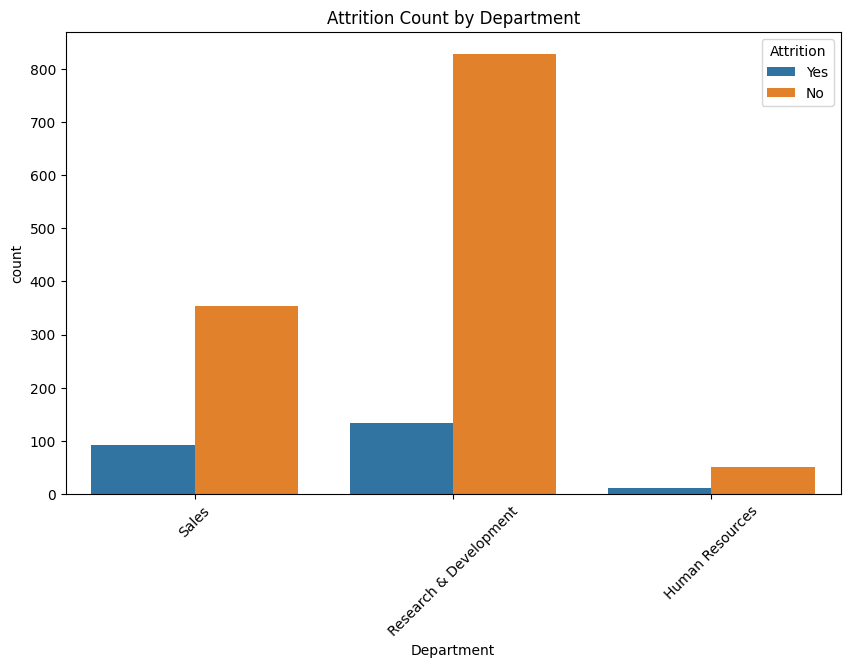

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition Count by Department')
plt.xticks(rotation=45)
plt.show()

# Percentage attrition by department
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print(dept_attrition)


#Salary Band

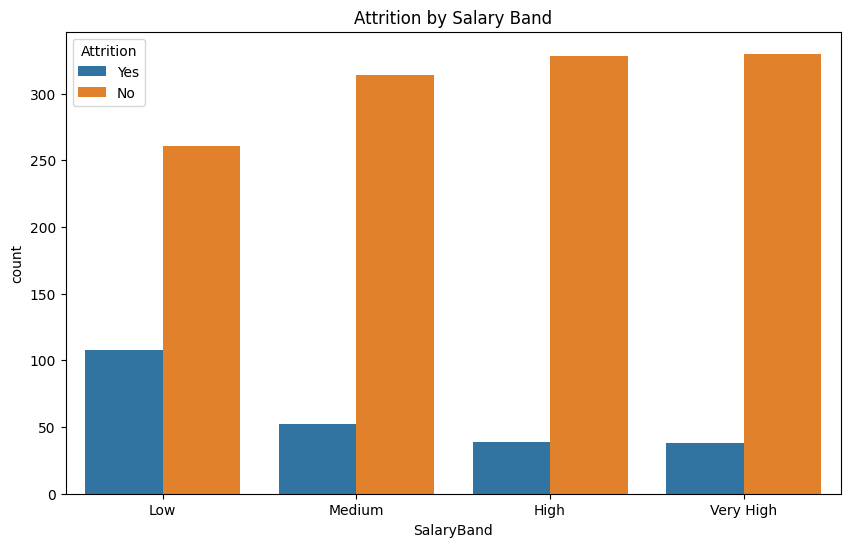

In [ ]:
df['SalaryBand'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='SalaryBand', hue='Attrition')
plt.title('Attrition by Salary Band')
plt.show()


#Promotion Vs Attrition

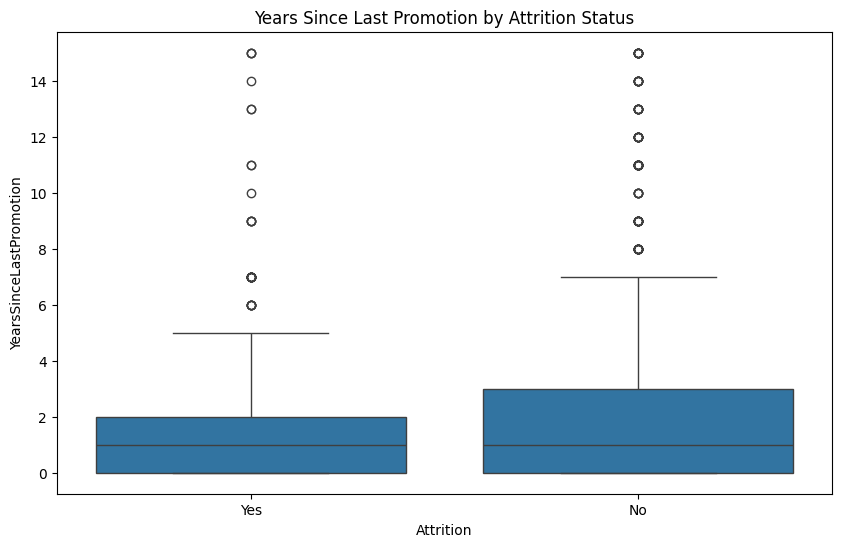

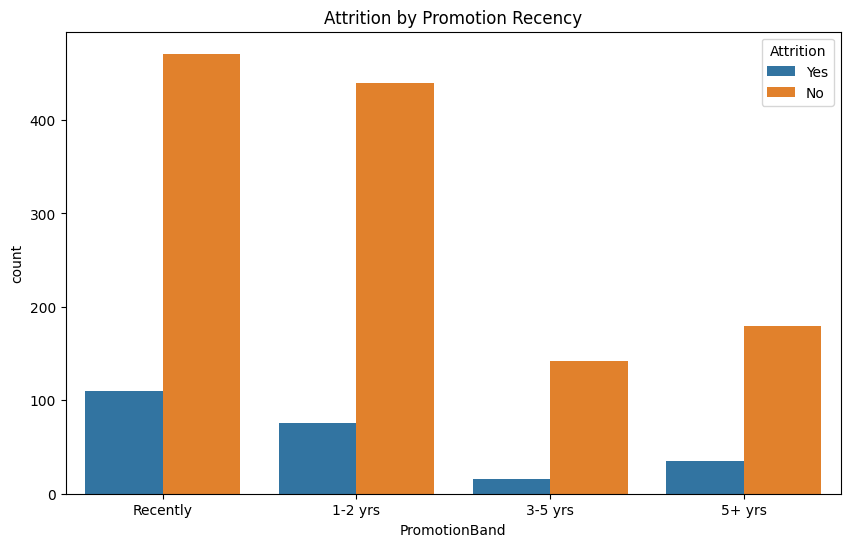

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion')
plt.title('Years Since Last Promotion by Attrition Status')
plt.show()

# You could also bin the promotion years
df['PromotionBand'] = pd.cut(df['YearsSinceLastPromotion'], bins=[-1,0,2,5,40], labels=['Recently', '1-2 yrs', '3-5 yrs', '5+ yrs'])

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PromotionBand', hue='Attrition')
plt.title('Attrition by Promotion Recency')
plt.show()


In [ ]:
df.shape

(1470, 35)

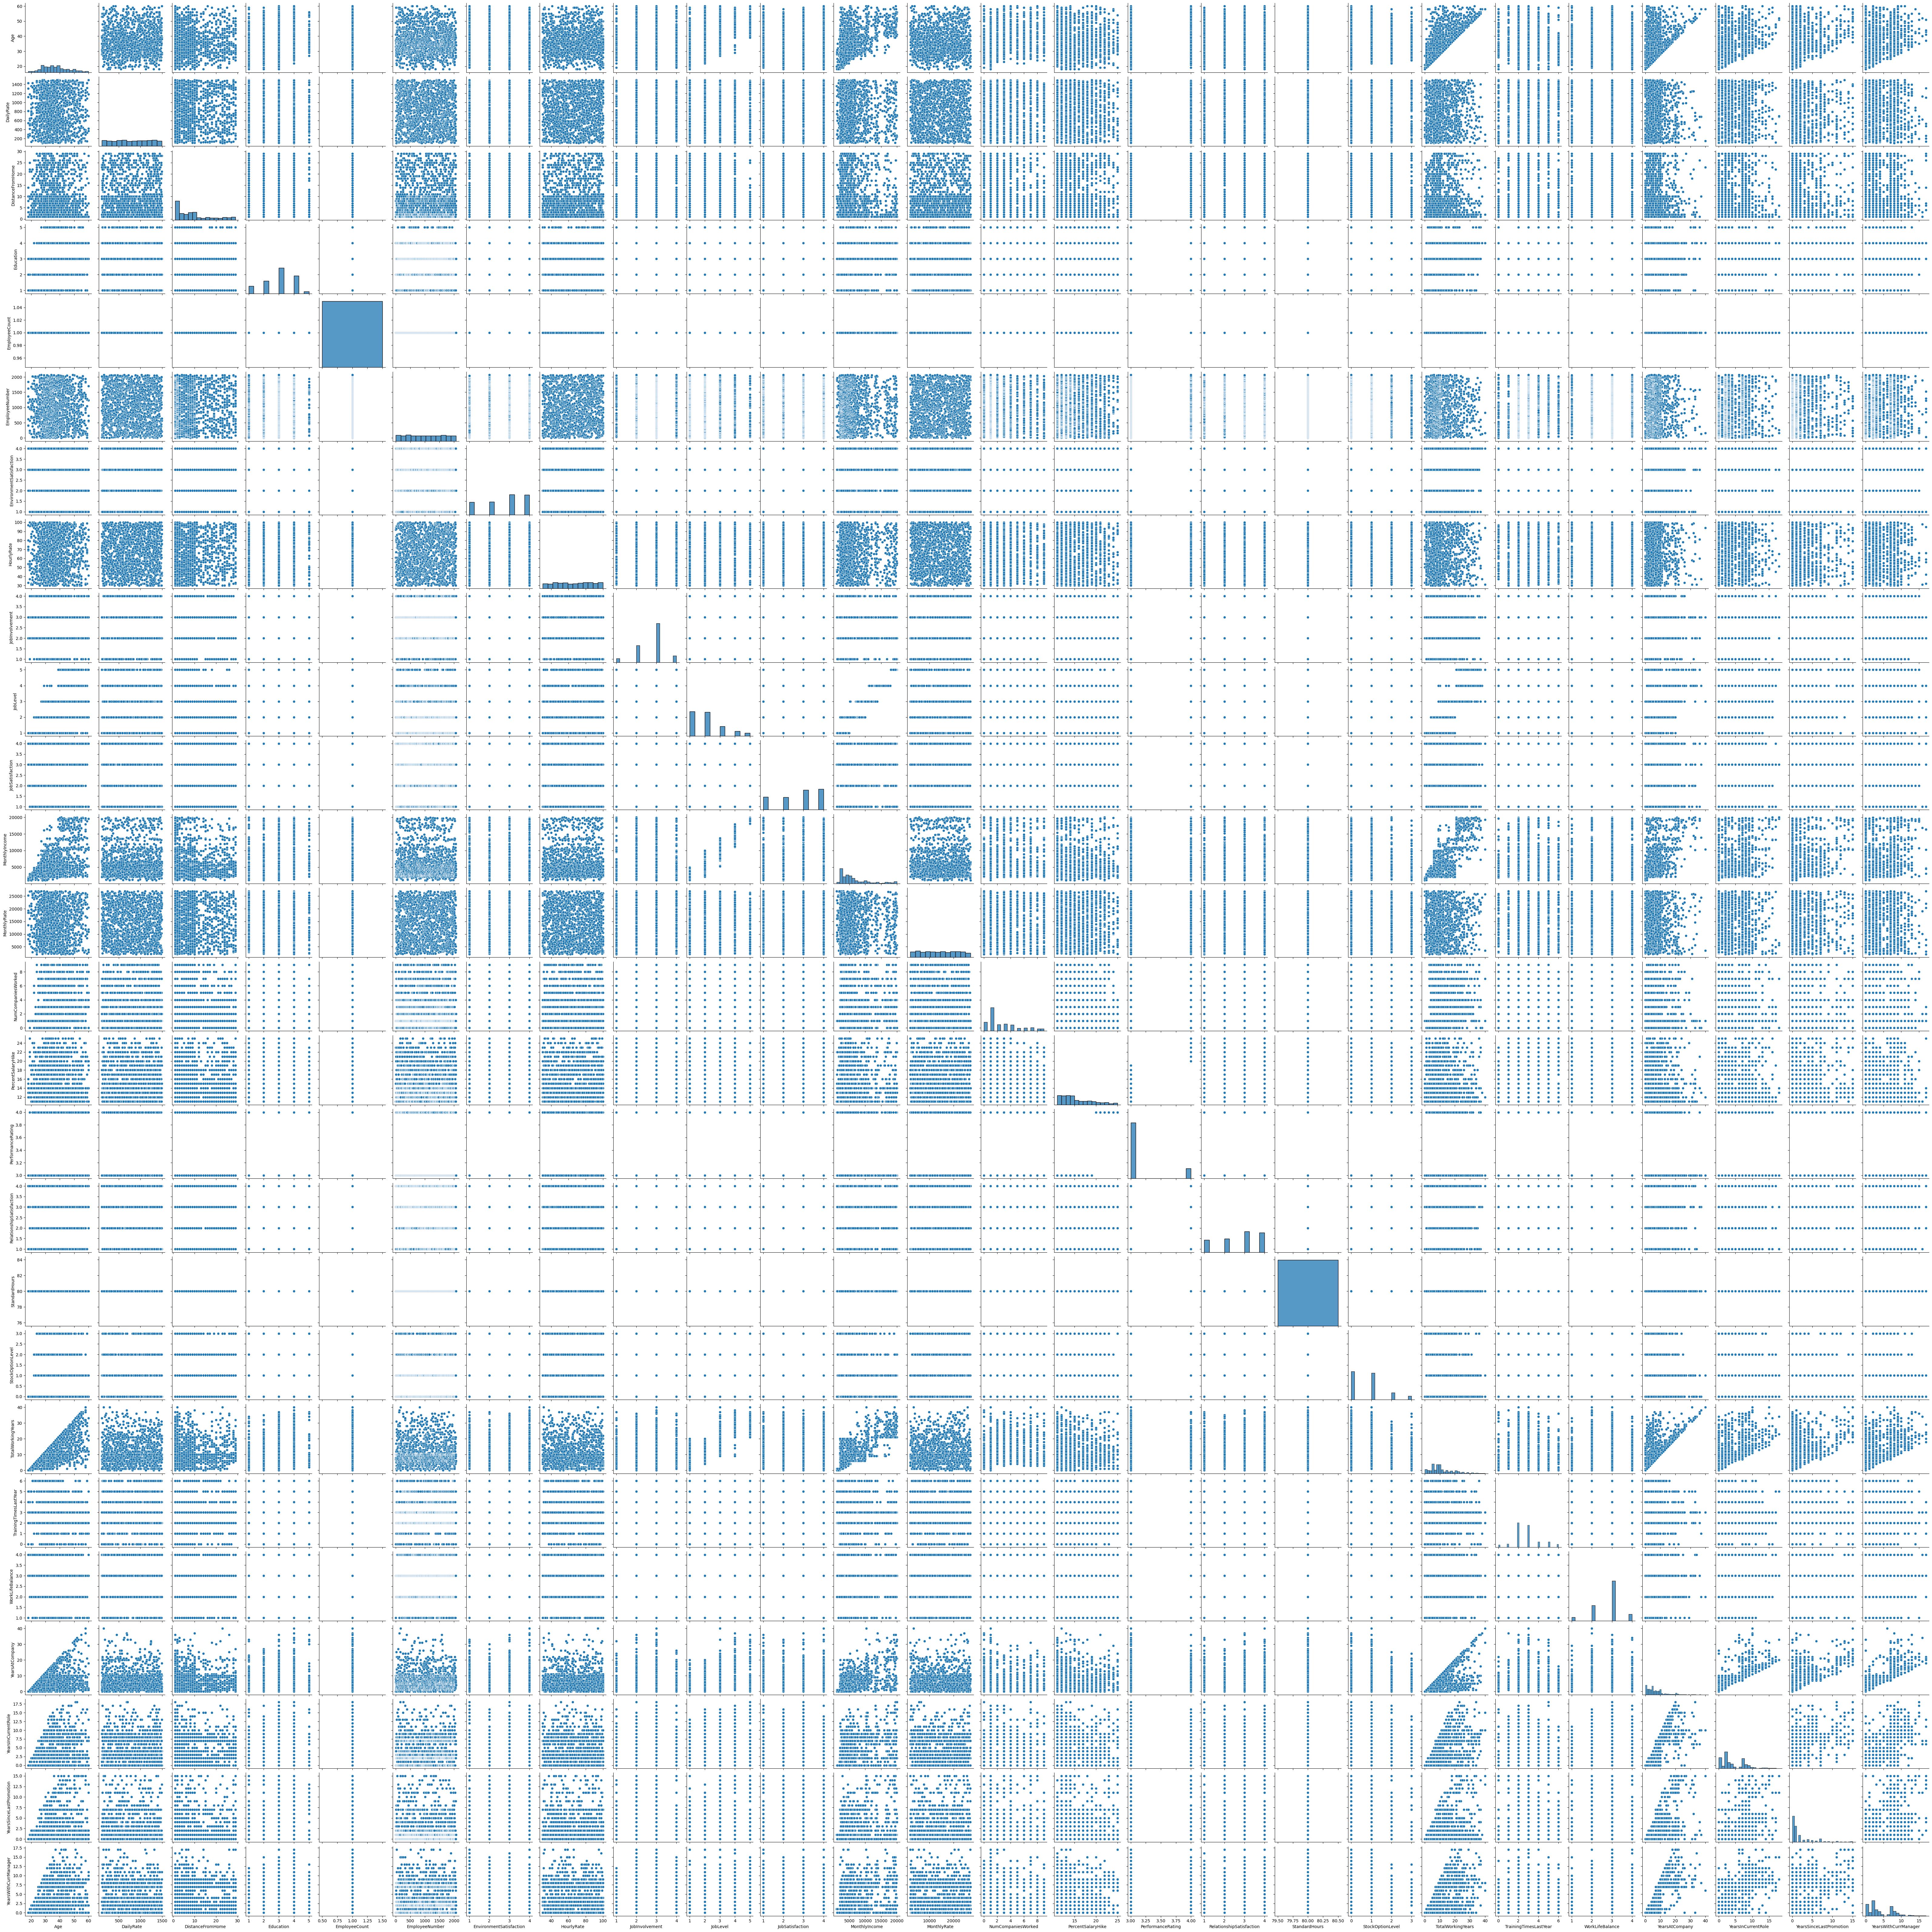

In [ ]:
sns.pairplot(df)

In [ ]:
df1= df
X = df1.drop('Attrition', axis=1)
y = df1['Attrition']

In [ ]:
y.shape

(1470,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7653061224489796

Classification Report:
               precision    recall  f1-score   support

          No       0.87      0.85      0.86       255
         Yes       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294


Confusion Matrix:
 [[218  37]
 [ 32   7]]
